## Análisis Exploratorio de Datos - Análisis Univariable

### By:
Rafael Garcia

### Date:
2026-08-20

### Description:

Este notebook corresponde a la **Tarea 3: Análisis Exploratorio de Datos (EDA)** del Proyecto 1 del curso de MLOps.

En esta primera parte se realiza el **análisis univariable** de cada atributo del dataset de Boston Housing, incluyendo estadísticas descriptivas, distribuciones, detección de outliers y reglas de validación de datos.

## 📚 Import libraries

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 💾 Load data

In [6]:
df = pd.read_parquet("../../data/02_intermediate/boston_housing_clean.parquet")
print(f"Dimensiones: {df.shape}")
df.head()

Dimensiones: (448, 15)


,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,4,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
3,5,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,NaN
4,7,0.08829,12.5,7.87,0.0,0.524,6.012,66.6,5.5605,5,311.0,15.2,395.60,12.43,22.9


In [7]:
# Separar columnas por tipo para el análisis
TARGET = "medv"
ID_COL = "ID"
CATEGORICAL_COLS = ["chas"]
ORDINAL_COLS = ["rad"]
NUMERIC_COLS = [
    col for col in df.columns if col not in [ID_COL, TARGET, *CATEGORICAL_COLS, *ORDINAL_COLS]
]

print(f"Variable objetivo: {TARGET}")
print(f"Categóricas: {CATEGORICAL_COLS}")
print(f"Ordinales: {ORDINAL_COLS}")
print(f"Numéricas continuas: {NUMERIC_COLS}")

Variable objetivo: medv
Categóricas: ['chas']
Ordinales: ['rad']
Numéricas continuas: ['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'tax', 'ptratio', 'black', 'lstat']


## 🔍 Análisis Univariable

Para cada atributo se analiza:
- Nombre y tipo de dato
- Porcentaje de valores nulos
- Duplicados exactos
- Estadísticas de tendencia central y dispersión
- Tipo de distribución
- Ruido y outliers
- Utilidad para el proyecto

### Variable objetivo: `medv` (Valor mediano de viviendas en miles USD)

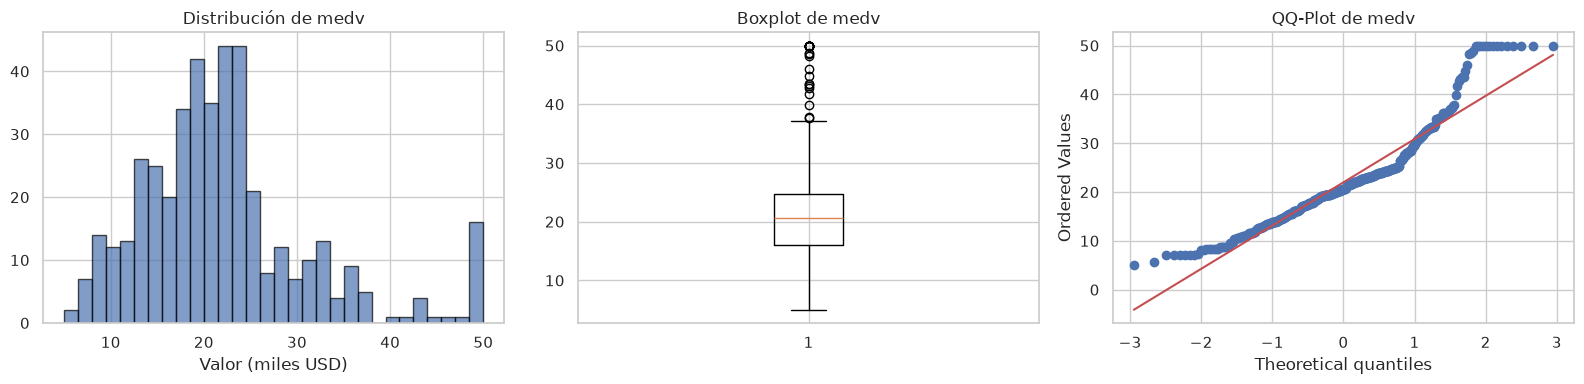

In [8]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma
axes[0].hist(df[TARGET].dropna(), bins=30, edgecolor="black", alpha=0.7)
axes[0].set_title(f"Distribución de {TARGET}")
axes[0].set_xlabel("Valor (miles USD)")

# Boxplot
axes[1].boxplot(df[TARGET].dropna())
axes[1].set_title(f"Boxplot de {TARGET}")

# QQ plot

stats.probplot(df[TARGET].dropna(), plot=axes[2])
axes[2].set_title(f"QQ-Plot de {TARGET}")

plt.tight_layout()
plt.show()

In [9]:
# Estadísticas descriptivas de medv
medv = df[TARGET].dropna()
print(f"=== {TARGET}: Valor mediano de viviendas (miles USD) ===")
print(f"Tipo de dato: {df[TARGET].dtype}")
print(f"Nulos: {df[TARGET].isnull().sum()} ({df[TARGET].isnull().mean() * 100:.2f}%)")
print("\nTendencia central:")
print(f"  Media:   {medv.mean():.4f}")
print(f"  Mediana: {medv.median():.4f}")
print(f"  Moda:    {medv.mode().values[0]:.4f}")
print(f"  Min:     {medv.min():.4f}")
print(f"  Max:     {medv.max():.4f}")
print("\nDispersión:")
print(f"  Rango:    {medv.max() - medv.min():.4f}")
print(f"  IQR:      {medv.quantile(0.75) - medv.quantile(0.25):.4f}")
print(f"  Varianza: {medv.var():.4f}")
print(f"  Std:      {medv.std():.4f}")
print(f"  Skewness: {medv.skew():.4f}")
print(f"  Kurtosis: {medv.kurtosis():.4f}")
print("\nDistribución: Asimétrica positiva (skew > 0), con cola derecha")
print("Nota: hay un techo en medv=50 que sugiere censura en los datos")

=== medv: Valor mediano de viviendas (miles USD) ===
Tipo de dato: float64
Nulos: 16 (3.57%)

Tendencia central:
  Media:   21.9880
  Mediana: 20.6000
  Moda:    50.0000
  Min:     5.0000
  Max:     50.0000

Dispersión:
  Rango:    45.0000
  IQR:      8.6000
  Varianza: 85.0006
  Std:      9.2196
  Skewness: 1.1539
  Kurtosis: 1.6607

Distribución: Asimétrica positiva (skew > 0), con cola derecha
Nota: hay un techo en medv=50 que sugiere censura en los datos


### Variables numéricas continuas

In [10]:
def analyze_numeric_variable(series, name):
    """Analiza una variable numérica y devuelve sus estadísticas."""
    data = series.dropna()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = ((data < lower_bound) | (data > upper_bound)).sum()

    result = {
        "Variable": name,
        "Tipo": str(series.dtype),
        "Nulos": series.isnull().sum(),
        "% Nulos": round(series.isnull().mean() * 100, 2),
        "Media": round(data.mean(), 4),
        "Mediana": round(data.median(), 4),
        "Std": round(data.std(), 4),
        "Min": round(data.min(), 4),
        "Q1": round(q1, 4),
        "Q3": round(q3, 4),
        "Max": round(data.max(), 4),
        "IQR": round(iqr, 4),
        "Skewness": round(data.skew(), 4),
        "Kurtosis": round(data.kurtosis(), 4),
        "Outliers_IQR": outliers,
    }
    return result

In [11]:
# Tabla resumen de todas las variables numéricas
all_numeric = [*NUMERIC_COLS, TARGET]
stats_list = [analyze_numeric_variable(df[col], col) for col in all_numeric]
stats_df = pd.DataFrame(stats_list).set_index("Variable")
stats_df

,Tipo,Nulos,% Nulos,Media,Mediana,Std,Min,Q1,Q3,Max,IQR,Skewness,Kurtosis,Outliers_IQR
Variable,,,,,,,,,,,,,,
crim,float64,5,1.12,3.8564,0.3523,8.2120,0.0063,0.0938,4.1499,73.5341,4.0561,4.4296,27.3423,48
zn,float64,2,0.45,9.1491,0.0000,20.7944,0.0000,0.0000,0.0000,100.0000,0.0000,2.6401,6.4893,103
indus,float64,6,1.34,12.0330,10.0100,7.0746,0.7400,5.8600,18.1000,27.7400,12.2400,0.1328,-1.3239,0
nox,float64,4,0.89,0.5713,0.5440,0.1173,0.3850,0.4720,0.6470,0.8710,0.1750,0.6373,-0.1245,0
rm,float64,6,1.34,6.2330,6.1520,0.6834,3.5610,5.8750,6.5380,8.7250,0.6630,0.4087,2.0163,26
age,float64,4,0.89,71.2601,82.1500,27.6711,6.0000,50.6750,95.0000,100.0000,44.3250,-0.7786,-0.6719,0
dis,float64,6,1.34,3.4924,2.7812,1.8951,1.1296,1.9804,4.5601,10.7103,2.5797,1.0563,0.4032,8
tax,float64,5,1.12,418.3567,384.0000,171.6113,188.0000,284.5000,666.0000,711.0000,381.5000,0.5525,-1.2849,0
ptratio,float64,2,0.45,18.4009,19.0000,2.2421,12.6000,16.8000,20.2000,21.2000,3.4000,-0.7291,-0.6134,0


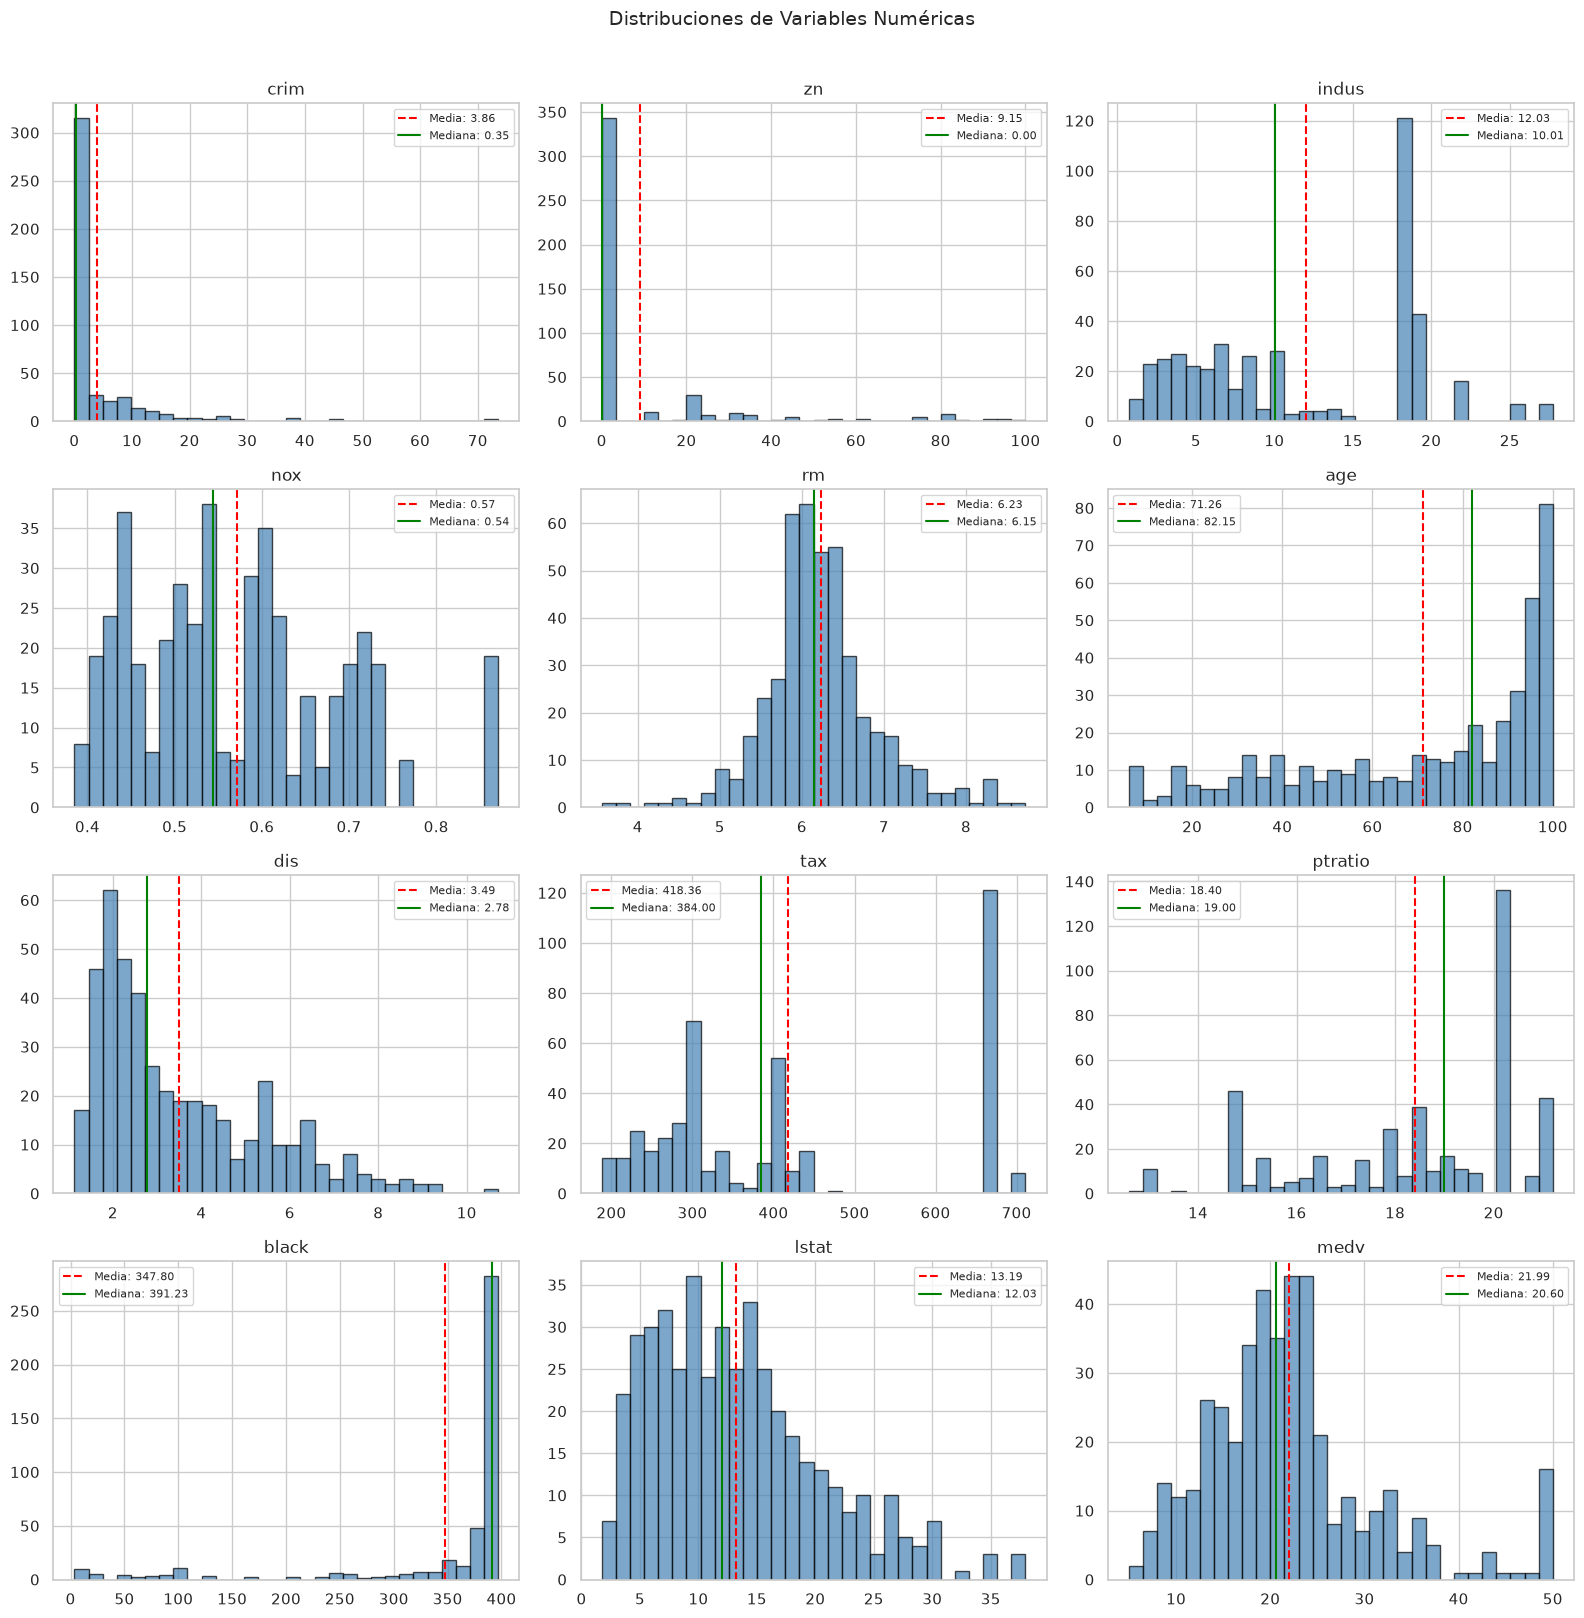

In [12]:
# Histogramas de todas las variables numéricas
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(all_numeric):
    data = df[col].dropna()
    axes[i].hist(data, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
    axes[i].axvline(data.mean(), color="red", linestyle="--", label=f"Media: {data.mean():.2f}")
    axes[i].axvline(
        data.median(), color="green", linestyle="-", label=f"Mediana: {data.median():.2f}"
    )
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

# Ocultar ejes sobrantes
for j in range(len(all_numeric), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribuciones de Variables Numéricas", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_30441/3827772374.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(data, vert=True)
/tmp/ipykernel_30441/3827772374.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(data, vert=True)
/tmp/ipykernel_30441/3827772374.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(data, vert=True)
/tmp/ipykernel_30441/3827772374.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(data, vert=True)
/tmp/ipykernel_30441/3827772374.py:7: MatplotlibDeprecationWarning: vert: bool w

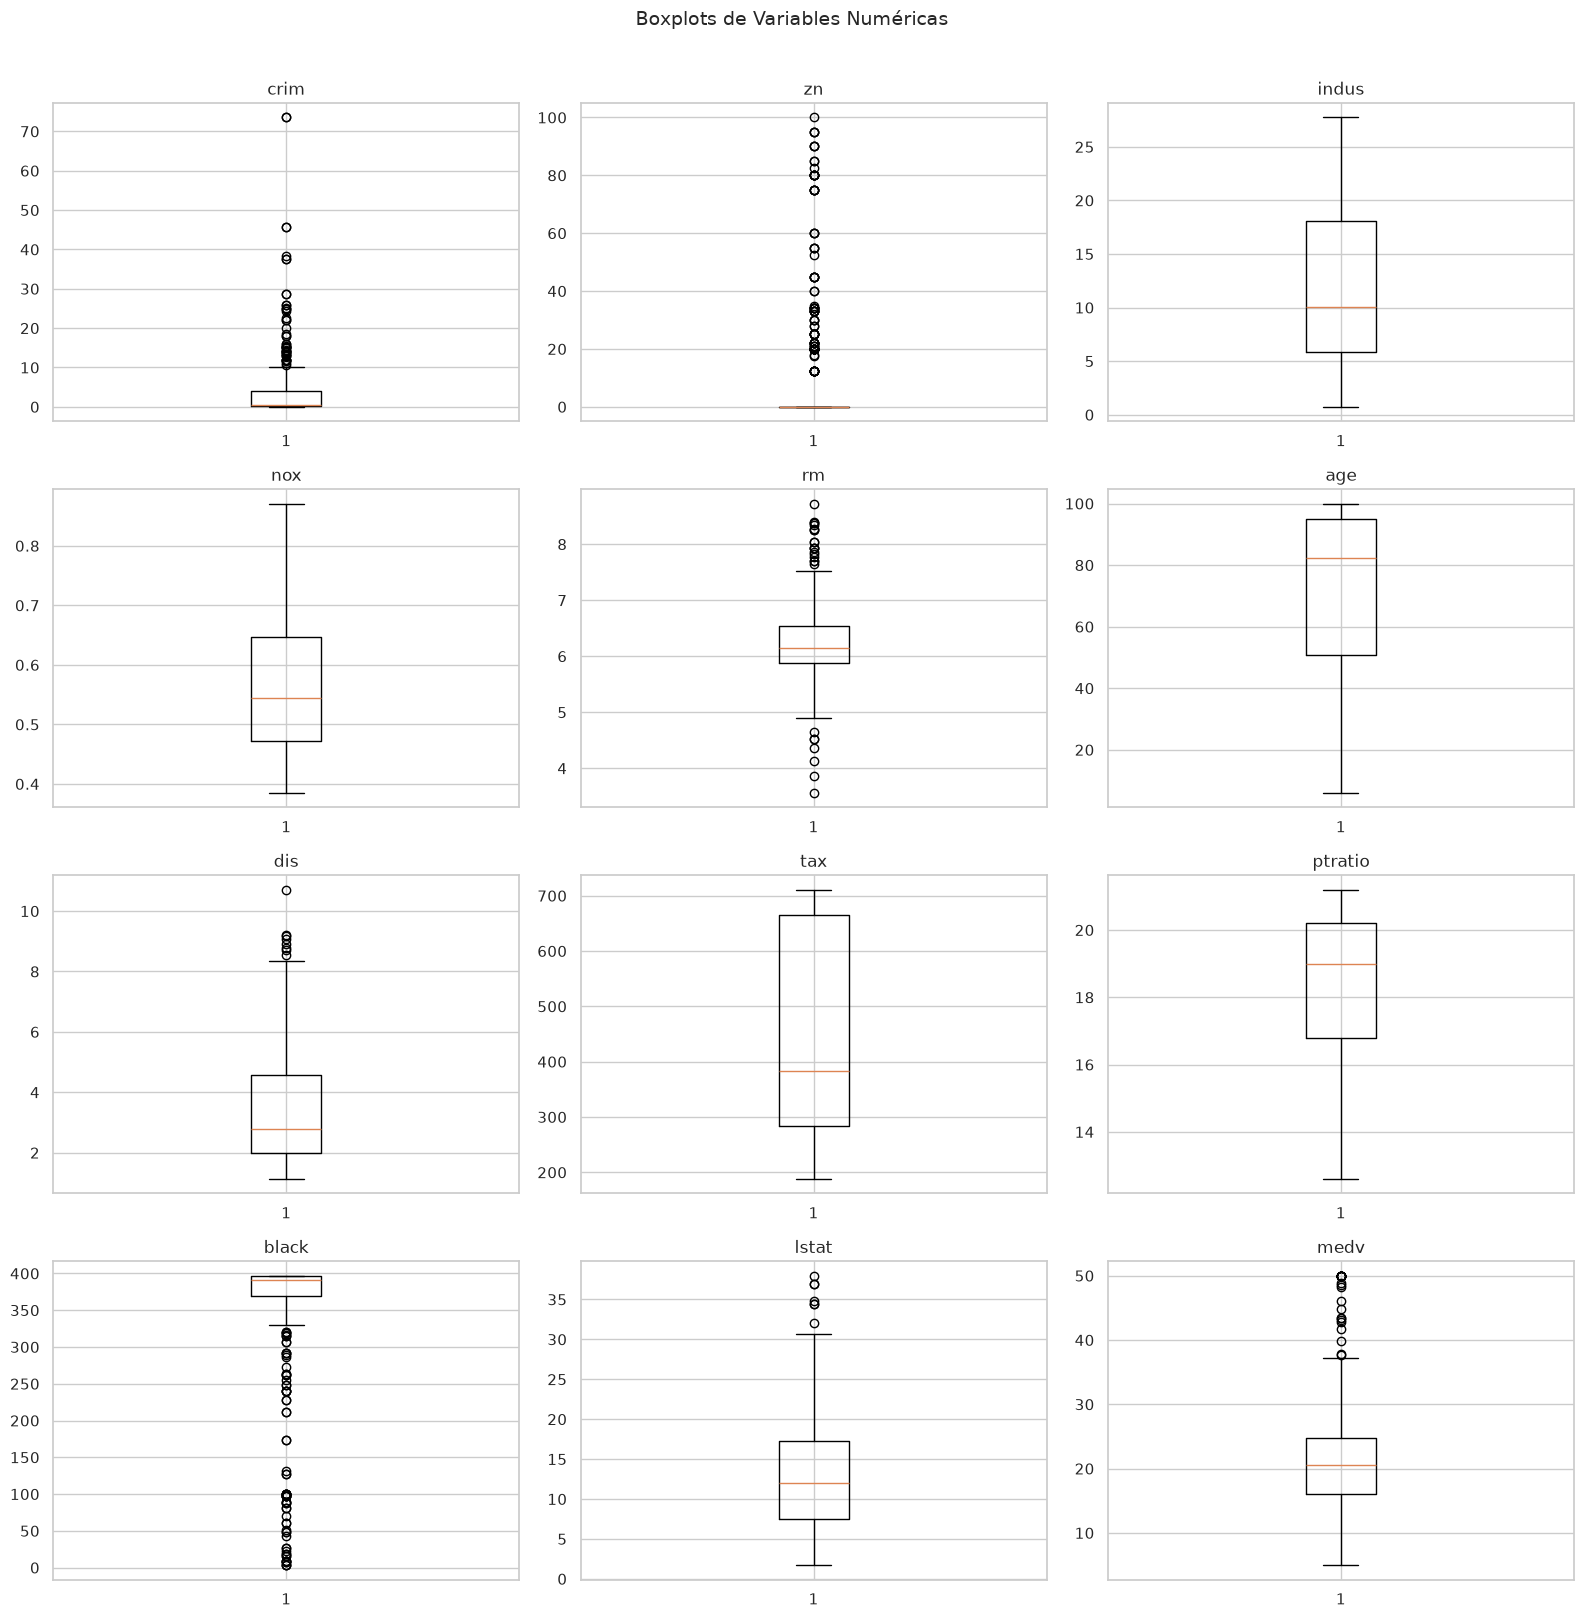

In [13]:
# Boxplots de todas las variables numéricas
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(all_numeric):
    data = df[col].dropna()
    axes[i].boxplot(data, vert=True)
    axes[i].set_title(col)

for j in range(len(all_numeric), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots de Variables Numéricas", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Variables categóricas y ordinales

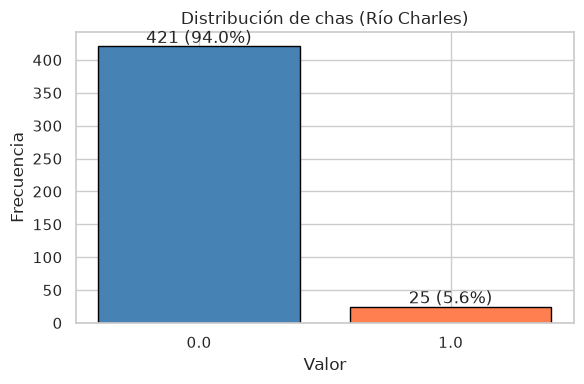

chas - Variable dummy del río Charles
  Tipo: categórica binaria
  Nulos: 2
  Distribución: altamente desbalanceada (94.3% = 0, 5.6% = 1)
  Utilidad: potencialmente útil como feature premium de ubicación


In [14]:
# Análisis de chas (variable dummy del río Charles)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
chas_counts = df["chas"].value_counts()
ax.bar(
    chas_counts.index.astype(str),
    chas_counts.values,
    color=["steelblue", "coral"],
    edgecolor="black",
)
ax.set_title("Distribución de chas (Río Charles)")
ax.set_xlabel("Valor")
ax.set_ylabel("Frecuencia")
for i, v in enumerate(chas_counts.values):
    ax.text(i, v + 5, f"{v} ({v / len(df) * 100:.1f}%)", ha="center")
plt.tight_layout()
plt.show()

print("chas - Variable dummy del río Charles")
print("  Tipo: categórica binaria")
print(f"  Nulos: {df['chas'].isnull().sum()}")
print("  Distribución: altamente desbalanceada (94.3% = 0, 5.6% = 1)")
print("  Utilidad: potencialmente útil como feature premium de ubicación")

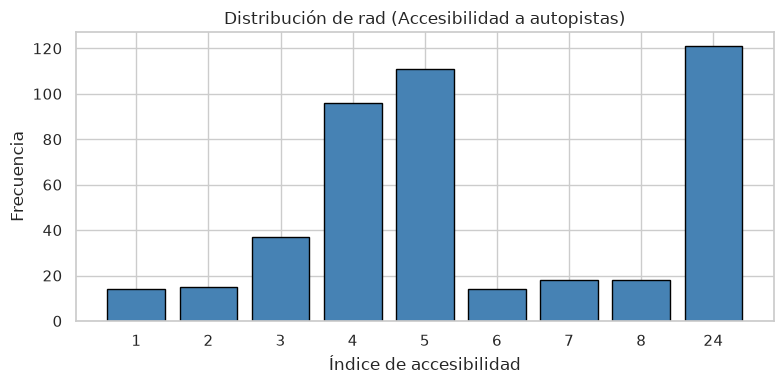

rad - Índice de accesibilidad a autopistas radiales
  Tipo: ordinal (entero)
  Nulos: 4
  Valores únicos: 9
  Distribución: bimodal, concentrada en valores 4-5 y 24
  Nota: el valor 24 tiene alta frecuencia (121 registros), podría representar una categoría especial


In [15]:
# Análisis de rad (índice de accesibilidad a autopistas)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
rad_counts = df["rad"].value_counts().sort_index()
ax.bar(rad_counts.index.astype(str), rad_counts.values, color="steelblue", edgecolor="black")
ax.set_title("Distribución de rad (Accesibilidad a autopistas)")
ax.set_xlabel("Índice de accesibilidad")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print("rad - Índice de accesibilidad a autopistas radiales")
print("  Tipo: ordinal (entero)")
print(f"  Nulos: {df['rad'].isnull().sum()}")
print(f"  Valores únicos: {df['rad'].nunique()}")
print("  Distribución: bimodal, concentrada en valores 4-5 y 24")
print(
    "  Nota: el valor 24 tiene alta frecuencia (121 registros), podría representar una categoría especial"
)

### Resumen de análisis por variable

| Variable | Tipo | % Nulos | Distribución | Outliers (IQR) | Útil para el proyecto |
|----------|------|---------|-------------|---------|----------------------|
| `crim` | float, continua no acotada | 1.12% | Fuertemente asimétrica positiva (skew=4.43), leptocúrtica | 48 | Sí — zonas de alta criminalidad tienen precios bajos |
| `zn` | float, acotada [0,100] | 0.45% | Asimétrica positiva, muchos ceros | 103 | Moderada — la mayoría de zonas tienen zn=0 |
| `indus` | float, acotada | 1.34% | Bimodal, ligeramente asimétrica | 0 | Sí — proporción de uso industrial |
| `chas` | categórica binaria | 0.45% | Altamente desbalanceada (94% clase 0) | N/A | Moderada — efecto premium por ubicación |
| `nox` | float, acotada [0.38, 0.87] | 0.89% | Ligeramente asimétrica positiva | 0 | Sí — calidad ambiental |
| `rm` | float, acotada | 1.34% | Aproximadamente normal (skew=0.41) | 26 | **Alta** — correlación fuerte con medv |
| `age` | float, acotada [0,100] | 0.89% | Asimétrica negativa | 0 | Moderada — antigüedad de viviendas |
| `dis` | float, no acotada | 1.34% | Asimétrica positiva | 8 | Sí — distancia a centros de empleo |
| `rad` | ordinal (entero) | 0.89% | Bimodal (picos en 4-5 y 24) | N/A | Sí — accesibilidad a transporte |
| `tax` | float, acotada | 1.12% | Bimodal | 0 | Sí — carga impositiva |
| `ptratio` | float, acotada | 0.45% | Asimétrica negativa | 0 | Sí — calidad educativa |
| `black` | float, acotada [0, 396.9] | 0.67% | Fuertemente asimétrica negativa | 74 | Cuestionable — consideración ética |
| `lstat` | float, acotada | 0.22% | Asimétrica positiva | 7 | **Alta** — correlación más fuerte con medv |
| `medv` | float, acotada [5, 50] | 3.57% | Asimétrica positiva, techo en 50 | 27 | **Variable objetivo** |

### Detección de duplicados

In [16]:
# Filas exactamente duplicadas (excluyendo ID)
cols_sin_id = [col for col in df.columns if col != ID_COL]
n_duplicados = df.duplicated(subset=cols_sin_id, keep=False).sum()
print(f"Filas duplicadas (excluyendo ID): {n_duplicados}")

# Columnas duplicadas
cols_iguales = []
cols_list = list(df.columns)
for i in range(len(cols_list)):
    for j in range(i + 1, len(cols_list)):
        if df[cols_list[i]].equals(df[cols_list[j]]):
            cols_iguales.append((cols_list[i], cols_list[j]))

print(f"Columnas duplicadas: {len(cols_iguales)}")

Filas duplicadas (excluyendo ID): 173
Columnas duplicadas: 0


### Reglas de validación de datos

Con base en el análisis univariable, se proponen las siguientes reglas de validación para asegurar la calidad de los datos en futuras iteraciones:

In [17]:
# Reglas de validación de datos
VALIDATION_RULES = {
    "crim": {"min": 0, "max": 100, "type": "float", "nullable": True},
    "zn": {"min": 0, "max": 100, "type": "float", "nullable": True},
    "indus": {"min": 0, "max": 30, "type": "float", "nullable": True},
    "chas": {"values": [0, 1], "type": "category", "nullable": True},
    "nox": {"min": 0.3, "max": 0.9, "type": "float", "nullable": True},
    "rm": {"min": 3, "max": 9, "type": "float", "nullable": True},
    "age": {"min": 0, "max": 100, "type": "float", "nullable": True},
    "dis": {"min": 0.5, "max": 13, "type": "float", "nullable": True},
    "rad": {"min": 1, "max": 24, "type": "int", "nullable": True},
    "tax": {"min": 100, "max": 800, "type": "float", "nullable": True},
    "ptratio": {"min": 10, "max": 25, "type": "float", "nullable": True},
    "black": {"min": 0, "max": 400, "type": "float", "nullable": True},
    "lstat": {"min": 0, "max": 40, "type": "float", "nullable": True},
    "medv": {"min": 4, "max": 51, "type": "float", "nullable": True},
}

print("=== Reglas de validación de datos ===")
for col, rules in VALIDATION_RULES.items():
    if "values" in rules:
        print(
            f"  {col}: tipo={rules['type']}, valores={rules['values']}, nullable={rules['nullable']}"
        )
    else:
        print(
            f"  {col}: tipo={rules['type']}, rango=[{rules['min']}, {rules['max']}], nullable={rules['nullable']}"
        )

=== Reglas de validación de datos ===
  crim: tipo=float, rango=[0, 100], nullable=True
  zn: tipo=float, rango=[0, 100], nullable=True
  indus: tipo=float, rango=[0, 30], nullable=True
  chas: tipo=category, valores=[0, 1], nullable=True
  nox: tipo=float, rango=[0.3, 0.9], nullable=True
  rm: tipo=float, rango=[3, 9], nullable=True
  age: tipo=float, rango=[0, 100], nullable=True
  dis: tipo=float, rango=[0.5, 13], nullable=True
  rad: tipo=int, rango=[1, 24], nullable=True
  tax: tipo=float, rango=[100, 800], nullable=True
  ptratio: tipo=float, rango=[10, 25], nullable=True
  black: tipo=float, rango=[0, 400], nullable=True
  lstat: tipo=float, rango=[0, 40], nullable=True
  medv: tipo=float, rango=[4, 51], nullable=True


## 📊 Analysis of Results and Conclusions

### Resultados del análisis univariable

1. **Variables más relevantes para predecir `medv`** (por inspección visual de distribuciones): `rm` y `lstat` muestran distribuciones que sugieren relaciones fuertes con la variable objetivo.

2. **Variables con distribuciones problemáticas**:
   - `crim`: fuertemente sesgada, con la mayoría de valores cerca de 0 y outliers extremos. Candidata a transformación logarítmica.
   - `zn`: la mayoría de valores son 0, distribución tipo zero-inflated.
   - `black`: asimetría negativa extrema con outliers por debajo.

3. **Outliers significativos**: `crim` (48), `zn` (103), `black` (74) y `medv` (27) tienen la mayor cantidad de outliers por método IQR.

4. **Techo en `medv`**: se observa un acumulamiento de valores en medv=50, sugiriendo que los precios fueron censurados (capped) en el dataset original.

5. **Variable `chas`**: altamente desbalanceada (94% vs 6%), lo cual puede limitar su poder predictivo.

### Conclusiones

- El dataset presenta varias distribuciones no normales que requerirán transformaciones en el feature engineering.
- Los valores nulos están distribuidos uniformemente (< 4% por columna) y podrían manejarse con imputación o eliminación.
- Se definieron reglas de validación para 14 variables que pueden usarse en validación automatizada.

## 💡 Proposals and Ideas

1. Aplicar transformación `log(1 + x)` a `crim` y `lstat` para reducir la asimetría.
2. Evaluar si `zn` debería binarizarse (0 vs >0) dado que la mayoría de valores son 0.
3. Considerar eliminar o no usar `black` por razones éticas y porque su distribución es problemática.
4. Investigar si los registros con medv=50 son realmente censurados y evaluar su impacto.
5. Usar las reglas de validación definidas en el pipeline de datos automatizado.

## 📖 References

- Guía del proyecto (Tarea 3): [joserzapata.github.io/post/ciencia-datos-proyecto-python/3-analysis/](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/3-analysis/)
- Harrison, D. and Rubinfeld, D.L. (1978). *Hedonic housing prices and the demand for clean air*.
- Seaborn documentation: [seaborn.pydata.org](https://seaborn.pydata.org/)